## Crimes Against Women in India — EDA Project
**Dataset:** Crimes Against Women in India (2001–2010)   
**Goal:** Analyze patterns, trends, and outcomes of crimes against women across Indian states

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (shapiro, ttest_ind, chi2_contingency, norm)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

Data Loading and First Look

In [2]:
df = pd.read_csv("CrimeData.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               4165 non-null   str  
 1   Year               4165 non-null   int64
 2   Group              4165 non-null   str  
 3   SubGroup           4165 non-null   str  
 4   Acquitted          4165 non-null   int64
 5   No_Chargesheet     4165 non-null   int64
 6   Chargesheeted      4165 non-null   int64
 7   Withdrawn          4165 non-null   int64
 8   Convicted          4165 non-null   int64
 9   False_Cases        4165 non-null   int64
10   Investigated       4165 non-null   int64
11   Not_Investigated   4165 non-null   int64
12   Pending_Inv_End    4165 non-null   int64
13   Pending_Inv        4165 non-null   int64
14   Pending_Trial_End  4165 non-null   int64
15   Pending_Trial      4165 non-null   int64
16   Reported           4165 non-null   int64
17   Trial              4165 n

In [4]:
df.describe()

          Year  Acquitted  No_Chargesheet  Chargesheeted  Withdrawn  Convicted  False_Cases  Investigated  Not_Investigated  Pending_Inv_End  Pending_Inv  Pending_Trial_End  Pending_Trial  Reported     Trial  Trials_Completed  Gov_Withdrawn  Gov_Withdrawn_Inv  Total_Trial
count  4165.00    4165.00         4165.00        4165.00    4165.00    4165.00      4165.00       4165.00           4165.00          4165.00      4165.00            4165.00        4165.00   4165.00   4165.00           4165.00        4165.00            4165.00      4165.00
mean   2005.48     787.45           45.89         617.47      64.64     132.05        72.22        662.99              4.88           254.88       232.99            2316.76        2183.72    758.26    621.08            424.42           3.84               0.33      2798.25
std       2.88    1107.69          187.29        1939.64     319.28     542.91       354.02       2053.88             70.77           940.26       849.00            8119.39        7

In [5]:
print("Shape: ", df.shape)

Shape:  (4165, 22)


In [6]:
df.head()

                        Area  Year  Group  SubGroup  Acquitted  No_Chargesheet  Chargesheeted  Withdrawn  Convicted  False_Cases  Investigated  Not_Investigated  Pending_Inv_End  Pending_Inv  Pending_Trial_End  Pending_Trial  Reported  Trial  Trials_Completed  Gov_Withdrawn  Gov_Withdrawn_Inv  Total_Trial
0  Andaman & Nicobar Islands  2001   Rape  01. Rape          5               2              3          0          0            0             5                 0                1            3                 34             36         3      3                 5              0                  0           39
1             Andhra Pradesh  2001   Rape  01. Rape        731              22            769         35        197           74           791                 3              393          390               1974           2170       871    769               928              2                  0         2937
2          Arunachal Pradesh  2001   Rape  01. Rape          1               2 

In [7]:
print("Null Values: \n", df.isnull().sum())
print("No. of Duplicate rows: ", df.duplicated().sum())

Null Values: 
 Area                 0
Year                 0
Group                0
SubGroup             0
Acquitted            0
No_Chargesheet       0
Chargesheeted        0
Withdrawn            0
Convicted            0
False_Cases          0
Investigated         0
Not_Investigated     0
Pending_Inv_End      0
Pending_Inv          0
Pending_Trial_End    0
Pending_Trial        0
Reported             0
Trial                0
Trials_Completed     0
Gov_Withdrawn        0
Gov_Withdrawn_Inv    0
Total_Trial          0
No. of Duplicate rows:  0


Data Cleaning

In [8]:
df.rename(columns={
    'Area_Name': 'Area',
    'Year': 'Year',
    'Group_Name': 'Group',
    'Sub_Group_Name': 'SubGroup',
    'Cases_Acquitted_or_Discharged': 'Acquitted',
    'Cases_charge_sheets_were_not_laid_but_Final_Report_submitted': 'No_Chargesheet',
    'Cases_Chargesheeted': 'Chargesheeted',
    'Cases_Compounded_or_Withdrawn': 'Withdrawn',
    'Cases_Convicted': 'Convicted',
    'Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law': 'False_Cases',
    'Cases_Investigated_Chargesheets+FR_Submitted': 'Investigated',
    'Cases_not_Investigated_or_in_which_investigation_was_refused': 'Not_Investigated',
    'Cases_Pending_Investigation_at_Year_End': 'Pending_Inv_End',
    'Cases_Pending_Investigation_from_previous_year': 'Pending_Inv',
    'Cases_Pending_Trial_at_Year_End': 'Pending_Trial_End',
    'Cases_Pending_Trial_from_the_previous_year': 'Pending_Trial',
    'Cases_Reported': 'Reported',
    'Cases_Sent_for_Trial': 'Trial',
    'Cases_Trials_Completed': 'Trials_Completed',
    'Cases_Withdrawn_by_the_Govt': 'Gov_Withdrawn',
    'Cases_withdrawn_by_the_Govt_during_investigation': 'Gov_Withdrawn_Inv',
    'Total_Cases_for_Trial': 'Total_Trial'
}, inplace=True)

print("Clean Column Names:")
for col in df.columns:
    print(col)

Clean Column Names:
Area
Year
Group
SubGroup
Acquitted
No_Chargesheet
Chargesheeted
Withdrawn
Convicted
False_Cases
Investigated
Not_Investigated
Pending_Inv_End
Pending_Inv
Pending_Trial_End
Pending_Trial
Reported
Trial
Trials_Completed
Gov_Withdrawn
Gov_Withdrawn_Inv
Total_Trial


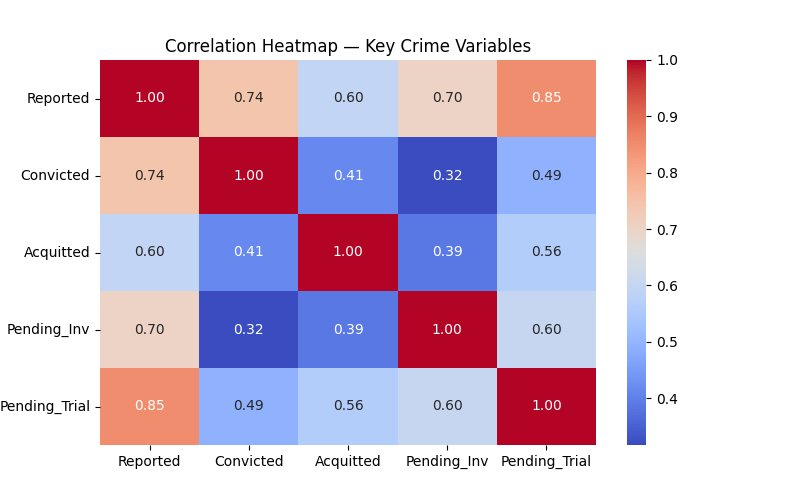

In [9]:
## Correlation Heatmap — Key Crime Variables
num_cols = [
    'Reported',
    'Convicted',
    'Acquitted',
    'Pending_Inv',
    'Pending_Trial'
]

plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Key Crime Variables", fontsize=14)
plt.show()

## Objective 1 : Distribution & Outlier Analysis of Cases Reported
                1. Group-wise total reported cases
                2. Boxplot of reported cases by crime group
                3. Count of high reported cases by crime group
                4. Reported vs Convicted comparison

In [10]:
group_reported = df.groupby("Group")["Reported"].sum().sort_values(ascending=False)
print("Total Reported Cases by Crime Group:")
print(group_reported)

group_order = group_reported.index

Total Reported Cases by Crime Group:
Group
Total Crime Against Women                             1504782
Cruelty by Husband and Relatives                       669539
Molestation                                            364836
Kidnapping & Abduction - Women & Girls                 190080
Rape                                                   190008
Sexual harassment                                      106311
Dowry Deaths                                            74351
Immoral Traffic (Prevention) Act, 1956                  48301
Indecent Representation of Women (Prohibition) Act       7468
Importation of Girls                                     2465
Sati Prevention Act                                         6
Name: Reported, dtype: int64


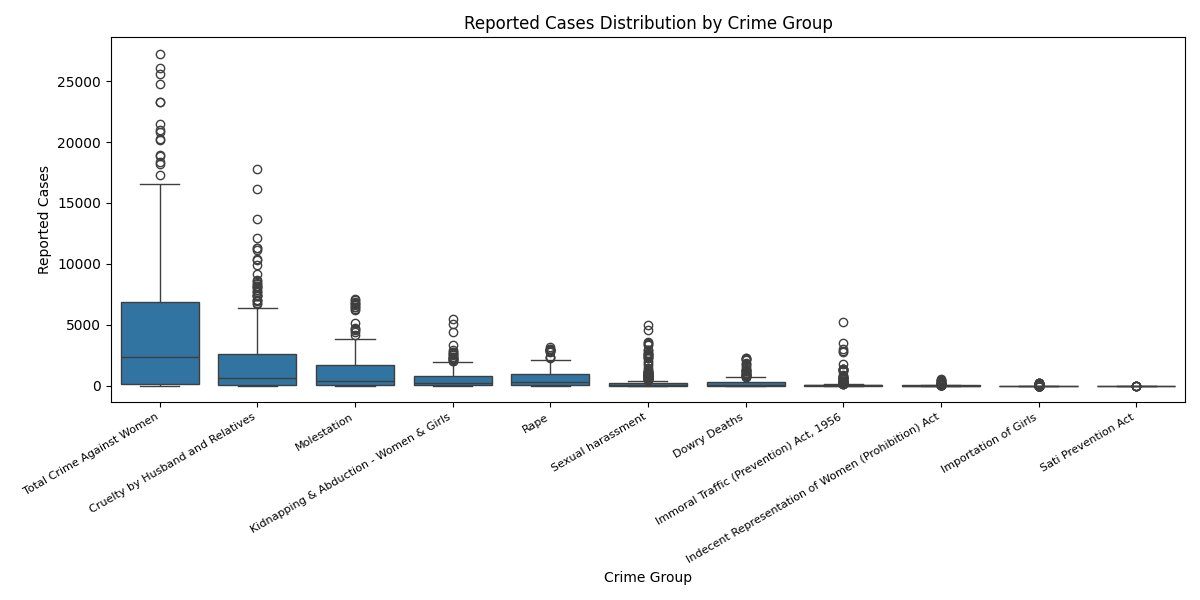

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Group", y="Reported", order=group_order)
plt.title("Reported Cases Distribution by Crime Group", fontsize=14)
plt.xlabel("Crime Group")
plt.ylabel("Reported Cases")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

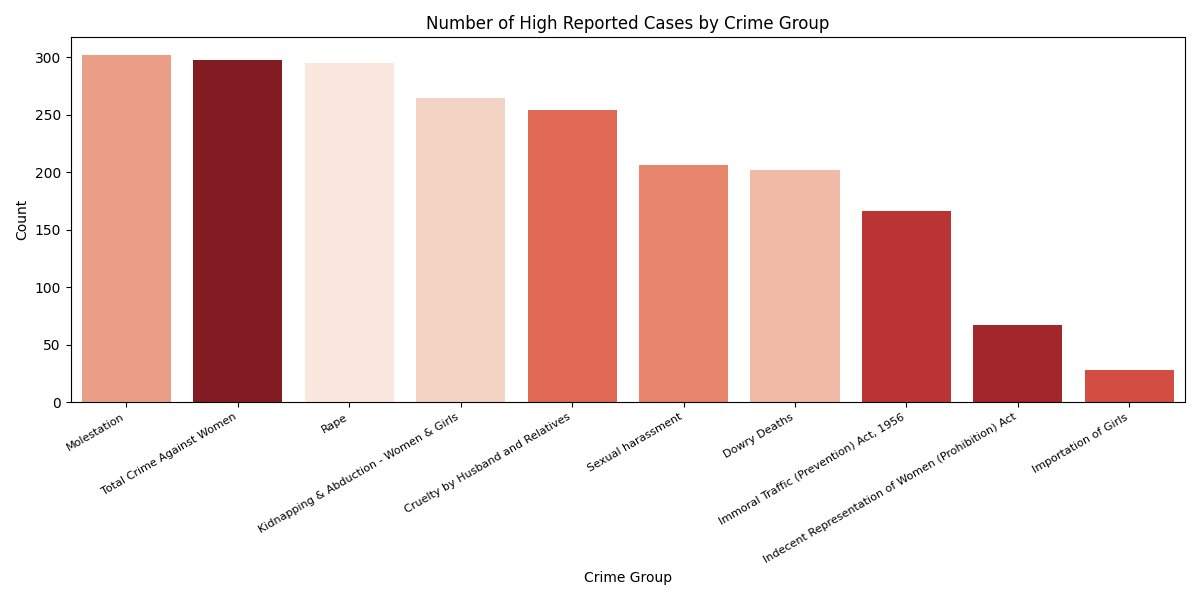

In [12]:
high_reported = df[df["Reported"] > df["Reported"].median()]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=high_reported,
    x="Group",
    order=high_reported["Group"].value_counts().index,
    hue="Group",
    palette="Reds",
    legend=False
)
plt.title("Number of High Reported Cases by Crime Group", fontsize=14)
plt.xlabel("Crime Group")
plt.ylabel("Count of High Reported Cases")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

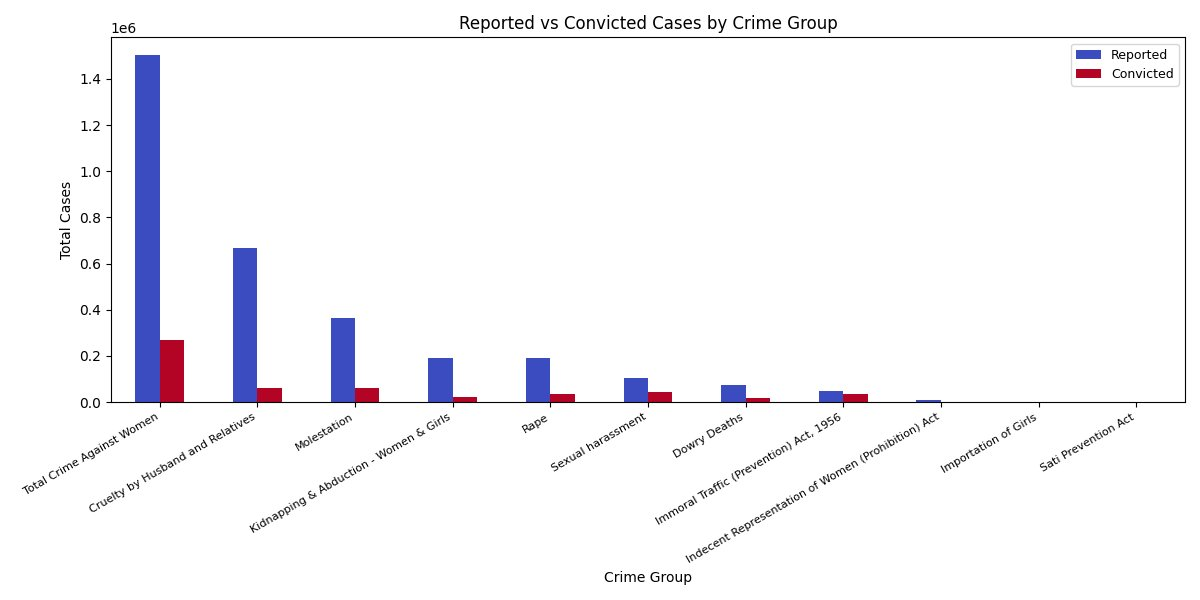

In [13]:
group_compare = df.groupby("Group")[["Reported", "Convicted"]].sum().loc[group_order]

group_compare.plot(kind="bar", figsize=(12, 6), colormap="coolwarm")
plt.title("Reported vs Convicted Cases by Crime Group", fontsize=14)
plt.xlabel("Crime Group")
plt.ylabel("Total Cases")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.legend(["Reported", "Convicted"], fontsize=9)
plt.tight_layout()
plt.show()

### **Insight** :
Cruelty by Husband and Relatives dominates total reported cases by a large margin.
Conviction numbers are consistently far lower than reported cases across all crime groups,
highlighting a significant gap in the justice delivery system.

## Objective 2 - State-wise & Year-wise Crime Trends
                1. Top 15 states by total cases reported
                2. Year-wise national trend of reported cases
                3. Cases Sent for Trial vs Cases Convicted for top 10 states

In [14]:
state_reported = df.groupby("Area")["Reported"].sum().sort_values(ascending=False).head(15)
print("Top 15 States by Total Reported Cases:")
print(state_reported)

Top 15 States by Total Reported Cases:
Area
Andhra Pradesh    390693
Uttar Pradesh     339141
Madhya Pradesh    286636
West Bengal       268019
Rajasthan         263320
Maharashtra       258022
Tamil Nadu        152965
Kerala            135002
Gujarat           131727
Assam             130128
Bihar             125869
Karnataka         119106
Odisha            114697
Haryana            86120
Delhi              71748
Name: Reported, dtype: int64


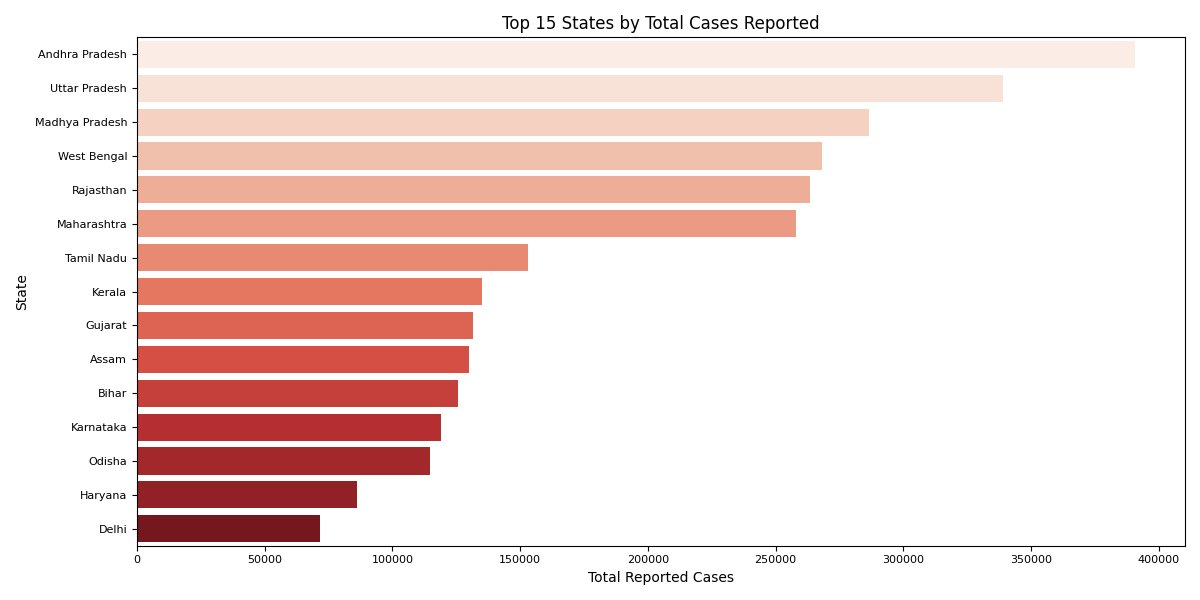

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=state_reported.values,
    y=state_reported.index,
    hue=state_reported.index,
    palette="Reds",
    legend=False
)
plt.title("Top 15 States by Total Cases Reported", fontsize=14)
plt.xlabel("Total Reported Cases")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Year-wise National Trend of Reported Cases:
Year
2001    283978
2002    281233
2003    278231
2004    304368
2005    305811
2006    324452
2007    364878
2008    190539
2009    402339
2010    422318
Name: Reported, dtype: int64


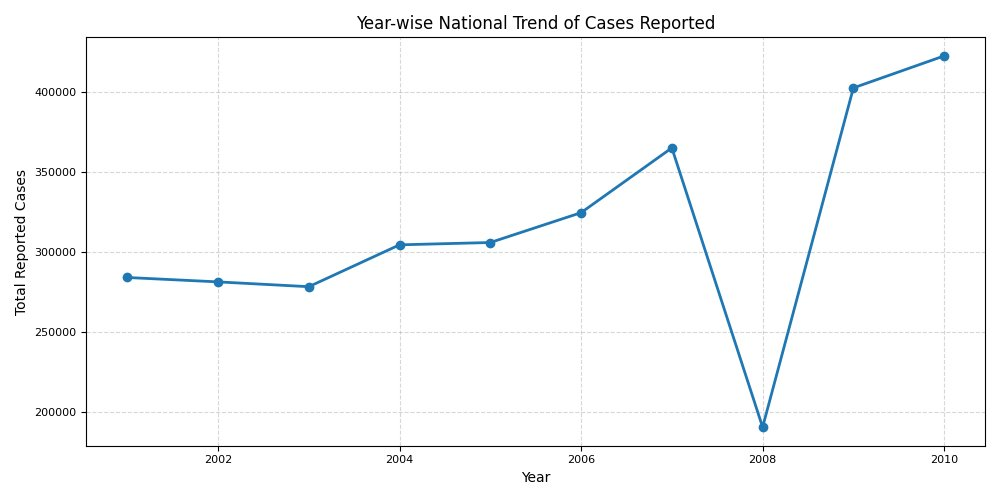

In [16]:
year_reported = df.groupby("Year")["Reported"].sum().sort_index()
print("Year-wise National Trend of Reported Cases:")
print(year_reported)

plt.figure(figsize=(10, 5))
plt.plot(year_reported.index, year_reported.values, marker="o", linewidth=2, color='steelblue')
plt.title("Year-wise National Trend of Cases Reported", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

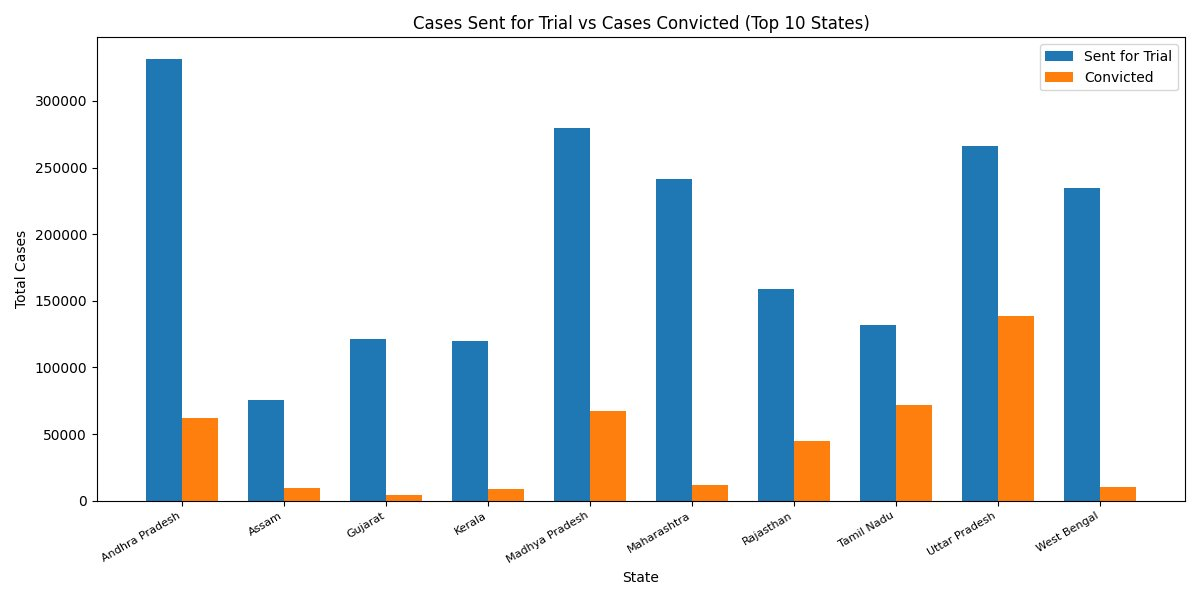

In [17]:
top10_states = df.groupby("Area")["Reported"].sum().sort_values(ascending=False).head(10).index
trial_convicted = df[df["Area"].isin(top10_states)].groupby("Area")[["Trial", "Convicted"]].sum()

x = np.arange(len(trial_convicted.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, trial_convicted["Trial"], width, label="Sent for Trial")
plt.bar(x + width/2, trial_convicted["Convicted"], width, label="Convicted")
plt.title("Cases Sent for Trial vs Cases Convicted (Top 10 States)", fontsize=14)
plt.xlabel("State")
plt.ylabel("Total Cases")
plt.xticks(x, trial_convicted.index, rotation=30, ha="right", fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

### **Insight**
Andhra Pradesh and Uttar Pradesh report the highest number of crimes against women.
Reported cases show a steady national increase from 2001 to 2010, indicating either
rising crimes or improved reporting. In all top states, convictions remain a tiny
fraction of cases sent for trial, reflecting systemic judicial delays.

## Objective 3 - Crime Group & Sub-Group Analysis
                1. Crime Group Share — Pie chart
                2. Top 10 Sub-Groups by total cases reported

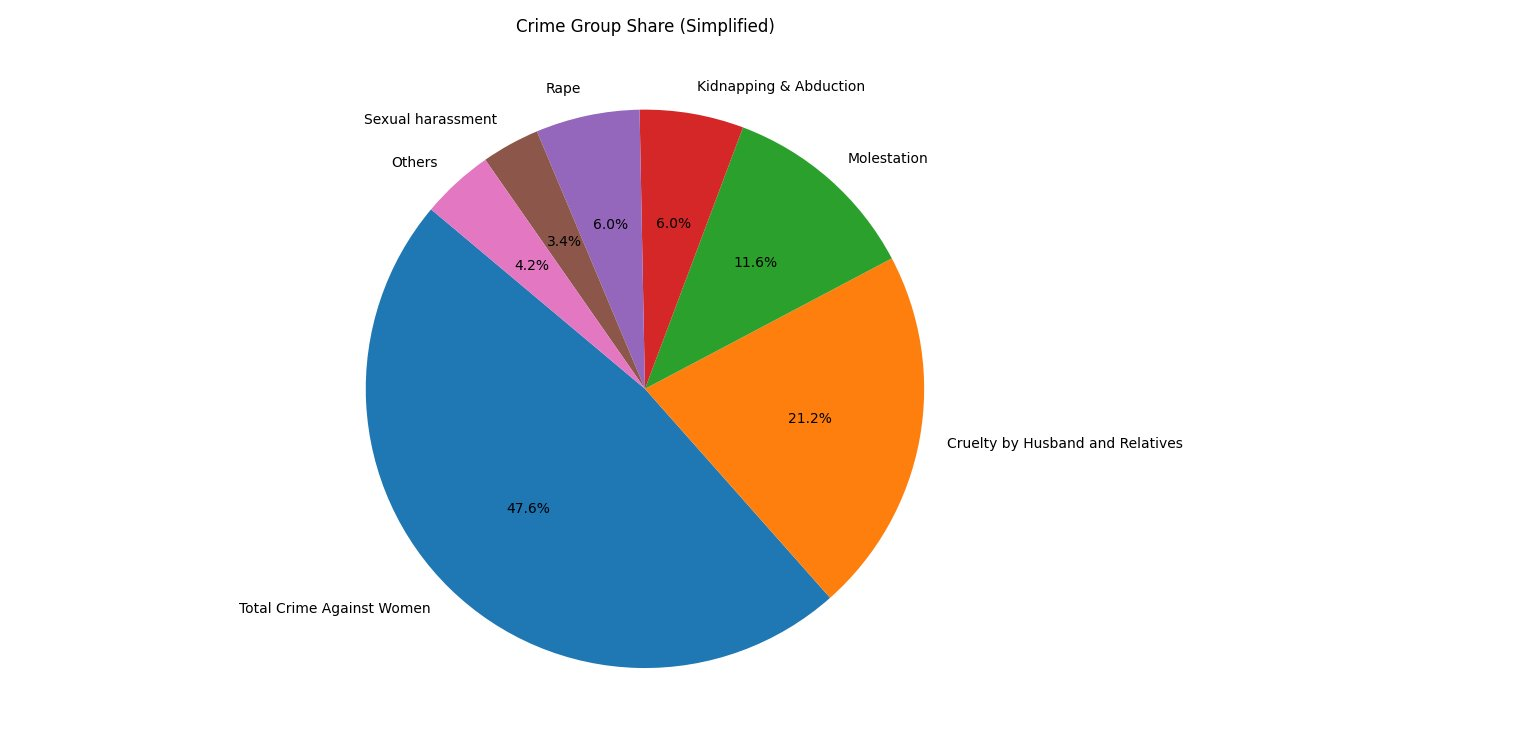

In [18]:
group_cases = df.groupby("Group")["Reported"].sum().sort_values(ascending=False)
group_cases = group_cases[group_cases.index != "Total Crime Against Women"]

top6 = group_cases.head(6)
others = pd.Series({"Others": group_cases.iloc[6:].sum()})
final_data = pd.concat([top6, others])

plt.figure(figsize=(7, 7))
plt.pie(
    final_data.values,
    labels=[i.split(" - ")[0] for i in final_data.index],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Crime Group Share — Crimes Against Women", fontsize=14)
plt.tight_layout()
plt.show()

Top 10 Sub-Groups by Total Reported Cases:
SubGroup
12. Total Crimes Against Women                           1504782
06. Cruelty by Husband and Relatives                      669539
04. Molestation                                           364836
02. Kidnapping & Abduction of Women & Girls               190080
01. Rape                                                  190008
05. Sexual Harassment                                     106311
03. Dowry Deaths                                           74351
08. Immoral Traffic Prevention Act                         48301
10. Indecent Representation of Women(Prohibition) Act       7468
09. Dowry Prohibition Act                                   1712
Name: Reported, dtype: int64


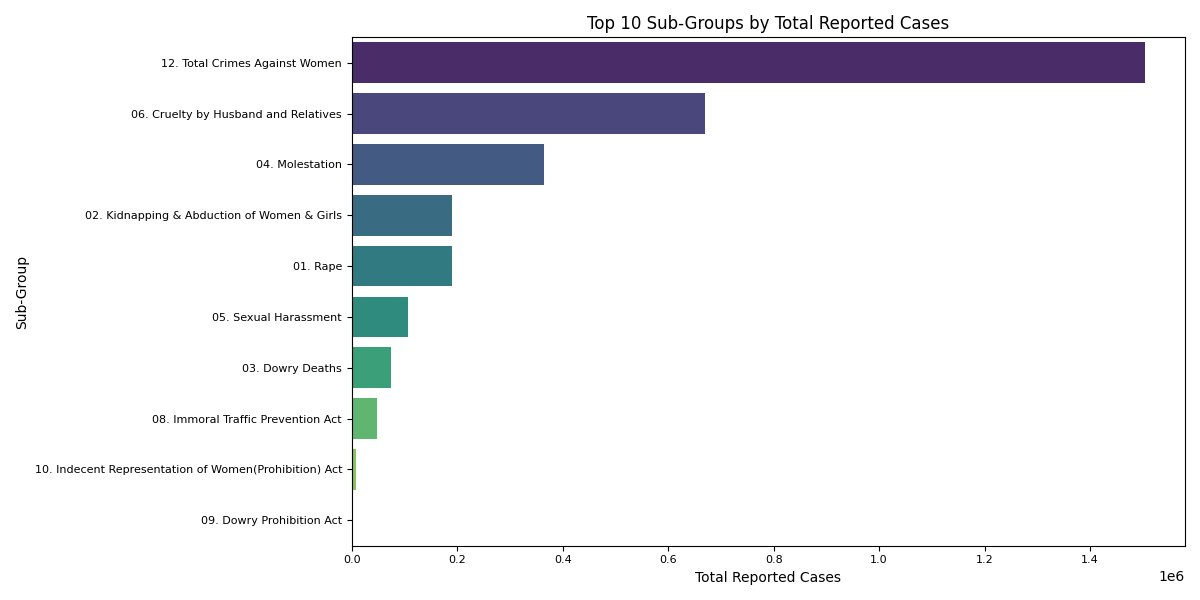

In [19]:
subgroup_cases = df.groupby("SubGroup")["Reported"].sum().sort_values(ascending=False).head(10)
print("Top 10 Sub-Groups by Total Reported Cases:")
print(subgroup_cases)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=subgroup_cases.values,
    y=subgroup_cases.index,
    hue=subgroup_cases.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Sub-Groups by Total Reported Cases", fontsize=14)
plt.xlabel("Total Reported Cases")
plt.ylabel("Sub-Group")
plt.tight_layout()
plt.show()

### **Insight**
Cruelty by Husband and Relatives accounts for the largest share of crimes against women,
followed by Molestation and Kidnapping & Abduction. Sub-group analysis confirms that
domestic crimes dominate, making them the most critical focus area for policy intervention.

## Objective 4 - Descriptive Statistics
              1. Descriptive Statistics
              2. T-test — Does Chargesheeting Rate Affect Cases Reported?

In [20]:
cols = ["Reported", "Chargesheeted", "Convicted", "Acquitted", "Trial"]
print("DESCRIPTIVE STATISTICS")
df[cols].describe().round(2)

DESCRIPTIVE STATISTICS


       Reported  Chargesheeted  Convicted  Acquitted     Trial
count   4165.00        4165.00    4165.00    4165.00   4165.00
mean     758.26         617.47     132.05     787.45    621.08
std     2318.53        1939.64     542.91    1107.69   1939.76
min        0.00           0.00       0.00       0.00      0.00
25%        0.00           0.00       0.00       2.00      0.00
50%       13.00           6.00       1.00     151.00      8.00
75%      356.00         291.00      48.00    1961.00    298.00
max    27244.00       23851.00   10307.00   11606.00  23851.00


In [21]:
# T-test
# H0: High and Low chargesheeted groups have same average reported cases
# H1: High chargesheeted group has significantly different reported cases

median_charge = df["Chargesheeted"].median()

high_group = df[df["Chargesheeted"] > median_charge]["Reported"]
low_group  = df[df["Chargesheeted"] <= median_charge]["Reported"]

t_stat, p_t = ttest_ind(high_group, low_group)

print("=" * 55)
print(" T-test: High Chargesheeted VS Low Chargesheeted")
print("=" * 55)
print(f" High Chargesheeted Mean : {high_group.mean():.2f}")
print(f" Low Chargesheeted Mean  : {low_group.mean():.2f}")
print(f" Difference              : {high_group.mean() - low_group.mean():.2f}")
print(f" T-statistic : {t_stat:.4f}")
print(f" p-value     : {p_t:.4f}")
print()

if p_t < 0.05:
    print(" Reject H0: Chargesheeting significantly affects reported cases")
else:
    print(" Cannot Reject H0: No significant difference found")

 T-test: High Chargesheeted VS Low Chargesheeted
 High Chargesheeted Mean : 1515.67
 Low Chargesheeted Mean  : 6.28
 Difference              : 1509.39
 T-statistic : 22.2146
 p-value     : 0.0000

 Reject H0: Chargesheeting significantly affects reported cases


### Insight
- **T-test:** Groups with higher chargesheeting have significantly more reported cases (p < 0.05), suggesting that areas with stronger legal action also tend to see more formal crime reporting.

## Objective 5 - Simple Linear Regression — Predicting Cases Reported
                Step 1 → Pre-model scatter              (relationship check)
                Step 2 → Train-Test Split               (data preparation)
                Step 3 → Train model + Coefficients     (modelling)
                Step 4 → R², MAE, RMSE                  (evaluation)
                Step 5 → Actual vs Predicted Plot        (visualization)
                Step 6 → Residual Plot                   (model diagnostics)

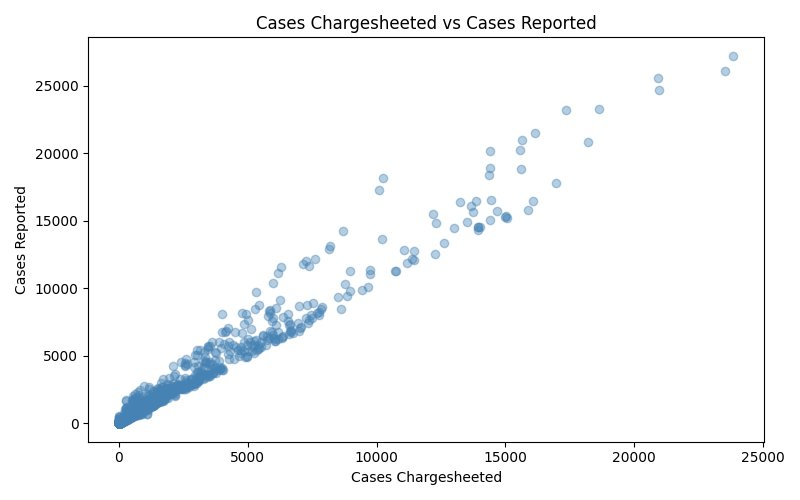

In [22]:
# Pre-model scatter — Chargesheeted vs Reported
plt.figure(figsize=(8, 5))
plt.scatter(df["Chargesheeted"], df["Reported"], alpha=0.4, color="steelblue")
plt.title("Cases Chargesheeted vs Cases Reported", fontsize=14)
plt.xlabel("Cases Chargesheeted")
plt.ylabel("Cases Reported")
plt.tight_layout()
plt.show()

In [23]:
# 80% training and 20% testing

X = df[["Chargesheeted"]]
y = df["Reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Testing set  : {X_test.shape[0]} rows")

Training set : 3332 rows
Testing set  : 833 rows


In [24]:
# Train the linear regression model on training data
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("=" * 55)
print("  Linear Regression — Coefficients")
print("=" * 55)
print(f"  Slope     : {slope:.4f}")
print(f"  Intercept : {intercept:.4f}")
print(f"\n  Equation : Reported = {slope:.4f} * Chargesheeted + {intercept:.4f}")

  Linear Regression — Coefficients
  Slope     : 1.1678
  Intercept : 33.5621

  Equation : Reported = 1.1678 * Chargesheeted + 33.5621


In [25]:
## Evaluation
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 35)
print("  Model Evaluation on Test Set")
print("=" * 35)
print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : {mae:.4f}")
print(f"  RMSE     : {rmse:.4f}")

  Model Evaluation on Test Set
  R² Score : 0.9706
  MAE      : 140.2771
  RMSE     : 416.3763


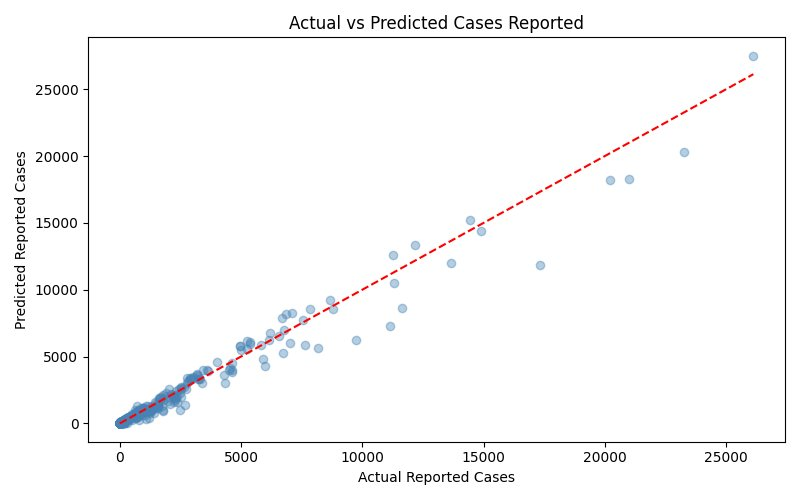

In [26]:
# Visualization - Actual vs Predicted
# Red dashed line = perfect prediction
# Points close to line = accurate model

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=1.5
)
plt.title("Actual vs Predicted Cases Reported", fontsize=14)
plt.xlabel("Actual Reported Cases")
plt.ylabel("Predicted Reported Cases")
plt.tight_layout()
plt.show()

### Insight
Chargesheeted cases are a strong predictor of total reported cases, as shown by a very high
R² of 0.97. The model fits well across most data points. Residual spread at higher prediction
values reflects states like Uttar Pradesh and Andhra Pradesh with unusually high reporting volumes.